There are 13 cases in which LP has profits in two steps
There are 10 cases in which LP has profits in one step


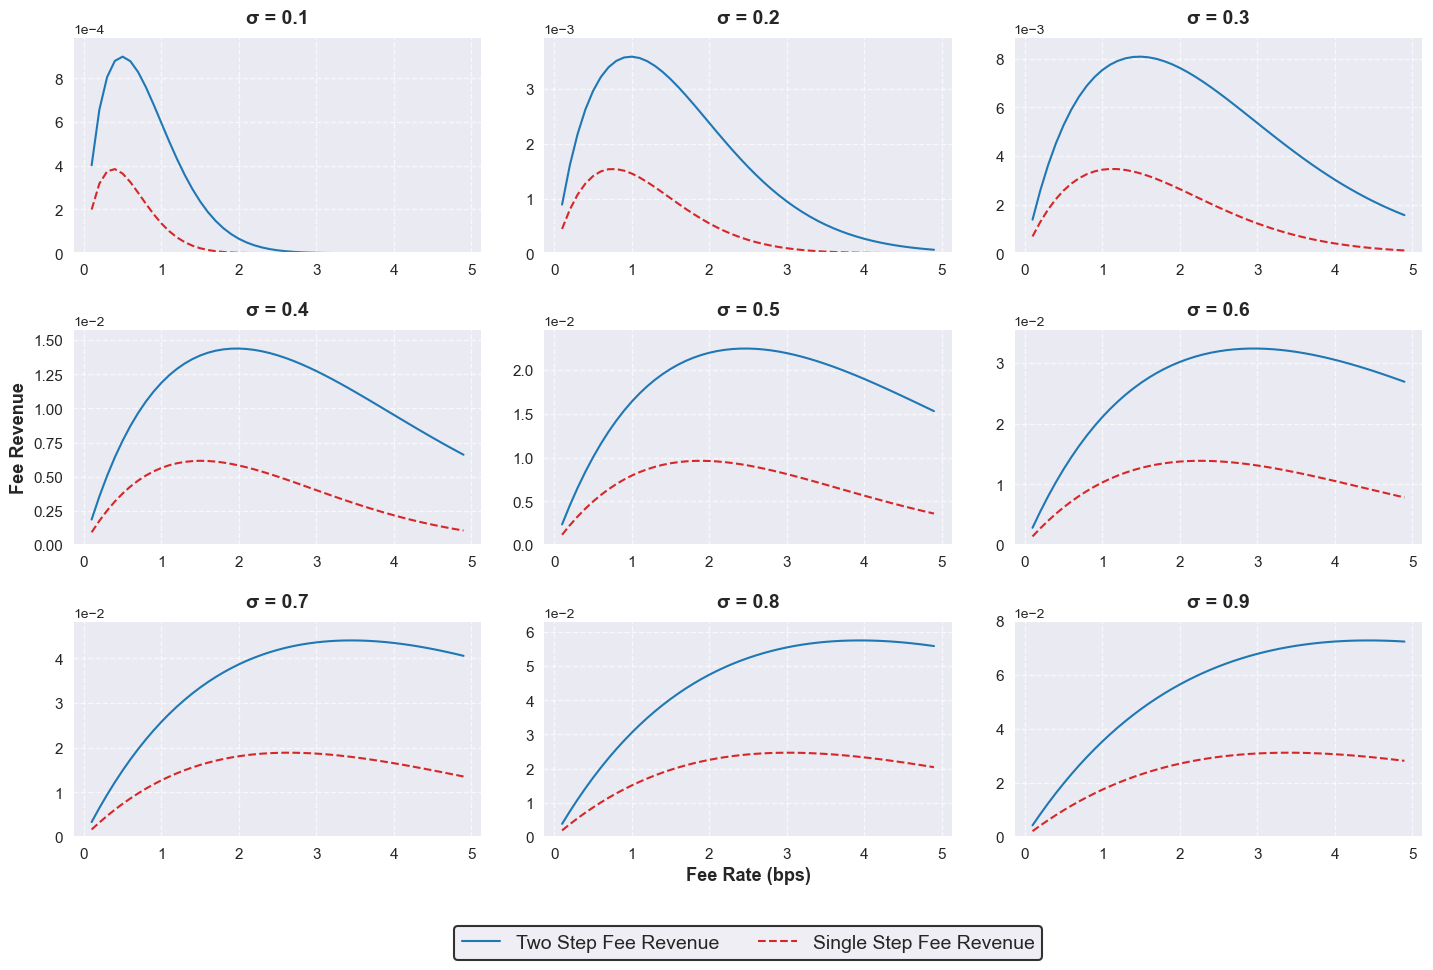

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_metrics(df, metric_names):
    # Get unique sigma values
    unique_sigmas = sorted(df['sigma'].unique())
    
    # Create a 3x3 grid of subplots with extra space for legend
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()  # Flatten for easier indexing
    
    # Use more professional colors and linestyles
    colors = ['#1f77b4', '#d62728']  # Blue and Red from matplotlib's default
    linestyles = ['-', '--']
    linewidth = 1.5  # Thicker lines for better visibility
    
    # Store legend handles and labels
    legend_handles = []
    legend_labels = []
    
    # Create plots for each sigma value
    for idx, sigma in enumerate(unique_sigmas):
        if idx >= 9:  # Safety check for more than 9 sigma values
            break
            
        # Filter data for current sigma
        sigma_data = df[df['sigma'] == sigma]
        
        # Create plot for each metric
        ax = axes[idx]
        for i, metric_name in enumerate(metric_names):
            # Convert gamma to basis points (multiply by 10000)
            line = ax.plot(sigma_data['gamma'] * 10000, sigma_data[metric_name], 
                         color=colors[i % len(colors)], 
                         linestyle=linestyles[i % len(linestyles)],
                         linewidth=linewidth)
            
            max_fee = sigma_data[metric_names].max().max()
            ax.set_ylim(0.0, max_fee * 1.1)
            
            # Collect legend info from first subplot only
            if idx == 0:
                legend_handles.extend(line)
                if metric_name == 'single_step_fee_revenue':
                    legend_labels.append('Single Step Fee Revenue')
                else:
                    legend_labels.append('Two Step Fee Revenue')
        
        # Customize plot
        ax.set_title(f'σ = {sigma:.1f}', fontsize=14, fontweight='bold', pad=10)
        
        
        # Scientific notation for y-axis
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        
        # Only add x-label to the bottom row (indices 6,7,8)
        if idx == 7:
            ax.set_xlabel('Fee Rate (bps)', fontsize=13, fontweight='bold')
        else:
            ax.set_xlabel('')
            
        # Only add y-label to the middle plot on the left side (index 3)
        if idx == 3:
            ax.set_ylabel('Fee Revenue', fontsize=13, fontweight='bold')
        else:
            ax.set_ylabel('')
            
        # Customize grid and spines
        ax.grid(True, linestyle='--', alpha=0.7)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        
        # Increase tick label size
        ax.tick_params(axis='both', which='major', labelsize=11)
    
    # Hide any unused subplots
    for idx in range(len(unique_sigmas), 9):
        axes[idx].set_visible(False)

    # Place legend at the bottom with enhanced styling
    legend = fig.legend(legend_handles, legend_labels, 
                       loc='upper center', bbox_to_anchor=(0.53, 0.05),
                       fontsize=14, ncol=2,
                       frameon=True, edgecolor='black',
                       borderaxespad=1)
    legend.get_frame().set_linewidth(1.5)

    # Adjust subplot spacing
    plt.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.12,
                       hspace=0.35, wspace=0.15)
    
    # Set figure background color to white
    fig.patch.set_facecolor('white')
    
    plt.show()
    
    
initial_pool_value = 2e6
df = pd.read_csv("/Users/haofu/Desktop/AMM/Dynamic_AMM/CPMM/TwoStep/results/two_step_result.csv")
df.loc[:,'single_step_fee_revenue'] = df.loc[:,'first_step_fee_revenue']
df.loc[:,'total_fee_revenue'] = df.loc[:,'single_step_fee_revenue'] + df.loc[:,'second_step_fee_revenue']
df.loc[:,'first_step_lp_revenue'] = df.loc[:,'first_step_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
df.loc[:,'lp_revenue'] = df.loc[:,'total_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
# check if there is any positive lp_revenue
print(f"There are {len(df[df['lp_revenue'] > 1e-8])} cases in which LP has profits in two steps")
print(f"There are {len(df[df['first_step_lp_revenue'] > 1e-8])} cases in which LP has profits in one step")


plot_metrics(df, ["total_fee_revenue", "single_step_fee_revenue"])

|    |   sigma |   single_step_opt_gamma |   single_step_fee |   two_step_opt_gamma |   first_step_fee |   second_step_fee |   two_step_fee_revenue |
|---:|--------:|------------------------:|------------------:|---------------------:|-----------------:|------------------:|-----------------------:|
|  0 |    0.1  |             3.77515e-05 |       0.000385185 |          4.92882e-05 |      0.000366103 |       0.000532134 |            0.000898237 |
|  1 |    0.11 |             4.15266e-05 |       0.000466073 |          5.4217e-05  |      0.000442983 |       0.000643882 |            0.00108687  |
|  2 |    0.12 |             4.53016e-05 |       0.000554665 |          5.91456e-05 |      0.000527186 |       0.000766271 |            0.00129346  |
|  3 |    0.13 |             4.90767e-05 |       0.00065096  |          6.40742e-05 |      0.000618711 |       0.000899303 |            0.00151801  |
|  4 |    0.14 |             5.28517e-05 |       0.000754958 |          6.90029e-05 |      0.0007175

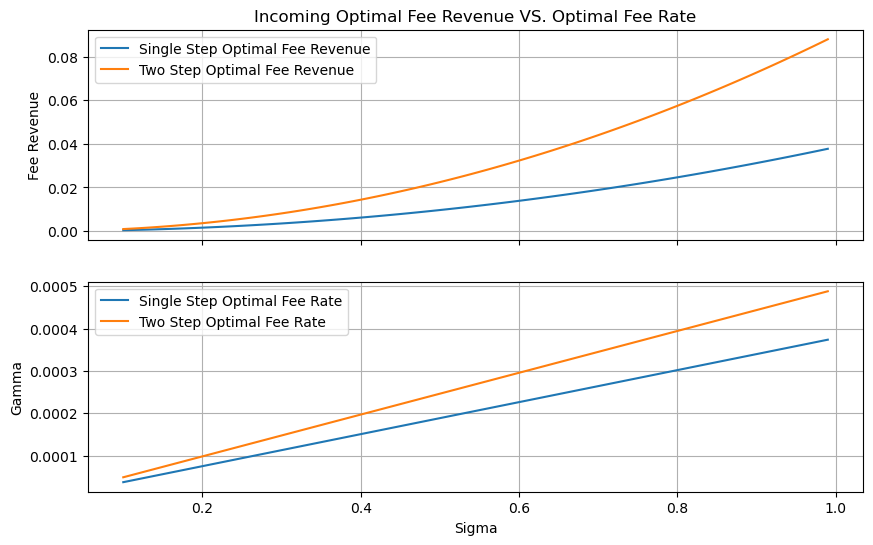

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



df = pd.read_csv("/home/shiftpub/Dynamic_AMM/CPMM/TwoStep/results/two_step_optimal_fee_results.csv")
df = df[df['sigma'] < 1]
print(df.head().to_markdown())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(df['sigma'], df['single_step_fee'], label='Single Step Optimal Fee Revenue')
ax1.plot(df['sigma'], df['two_step_fee_revenue'], label='Two Step Optimal Fee Revenue')
ax1.set_ylabel('Fee Revenue')
ax1.legend()
ax1.set_title('Incoming Optimal Fee Revenue VS. Optimal Fee Rate')
ax1.grid(True)

ax2.plot(df['sigma'], df['single_step_opt_gamma'], label='Single Step Optimal Fee Rate')
ax2.plot(df['sigma'], df['two_step_opt_gamma'], label='Two Step Optimal Fee Rate')
ax2.set_xlabel('Sigma')
ax2.set_ylabel('Gamma')
ax2.legend()
ax2.grid(True)
plt.show()
